In [1]:
# 1. Загрузите изображение в оттенках серого sar_1_gray.jpg. +
# 2. постройте гистограмму + 
# 3. реализуйте алгоритм гамма коррекции с параметром гамма <1, >1. + 
# 4. Сравните исходное изображение, скорректированное при помощи гамма-фильтра. MSE, SSIM.+
# 5. реализуйте алгоритм статистической цветокоррекции на основе статистики eq_gray.
# 6. Протестируйте работу алгоритмов пороговой фильтрации с различными параметрами.
# Для каждого решения - напечатайте результат

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import mean_squared_error, structural_similarity
from skimage import io, color, exposure, filters, util

<h1>1. Загрузка изображения</h1>

In [3]:
image = cv2.imread('sar_1_gray.jpg')

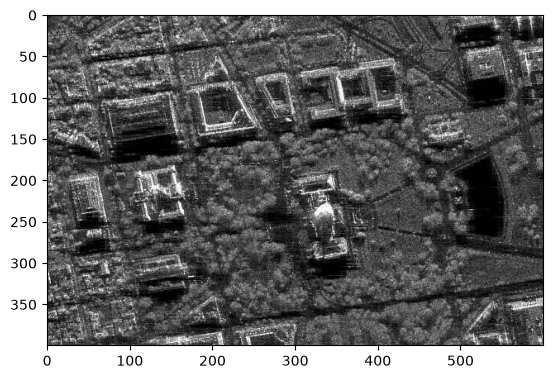

In [4]:
plt.imshow(image)

<h1>2. Гистограмма изображения</h1>

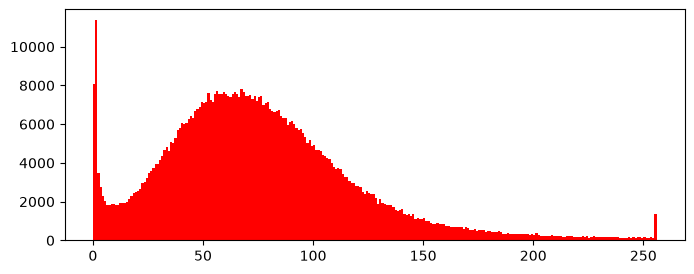

In [16]:
plt.figure(figsize=(8, 3))
plt.hist(image.ravel(), bins=256, range = [0, 256], color = 'red')
plt.show()

<h1>3. Гамма коррекция</h1>

Text(0.5, 1.0, 'gamma < 1')

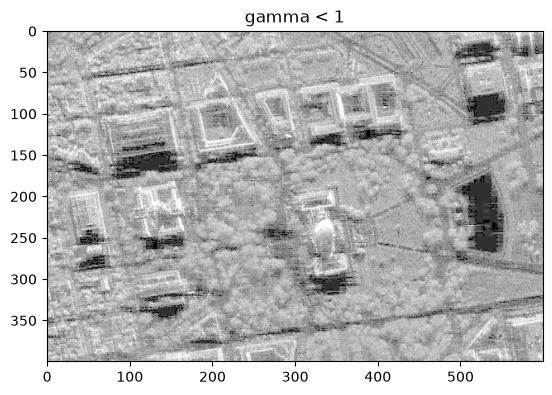

In [17]:
def gamma_correct(image, gamma):
    r_corrected = ((image / 255.0) ** gamma) * 255

    return r_corrected.astype(np.uint8)
    

img_gamma_1 = gamma_correct(image, 0.3)
plt.imshow(img_gamma_1)
plt.title('gamma < 1')

Text(0.5, 1.0, 'gamma > 1')

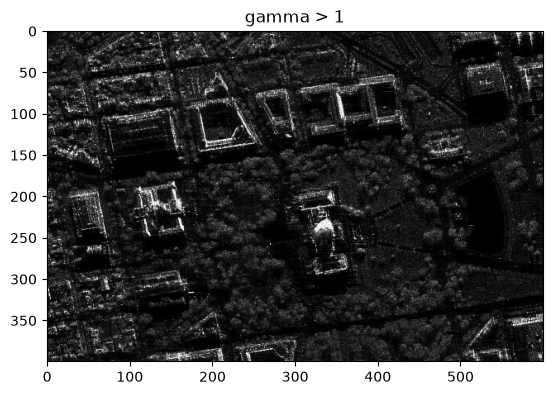

In [7]:
img_gamma_2 = gamma_correct(image, 2.0)
plt.imshow(img_gamma_2)
plt.title('gamma > 1')

<h1>4. Сравнение изображений</h1>

In [19]:
(ssim, diff) = structural_similarity(image, img_gamma_1, data_range=1.0, win_size=3, full= True)
diff = (diff * 255).astype("uint8")
print("SSIM for gamma < 1(gamma=0.3): {}".format(ssim))
mse = mean_squared_error(image, img_gamma_1)
print("MSE for gamma < 1(gamma=0.3): {}\n".format(mse))
(ssim, diff) = structural_similarity(image, img_gamma_2, data_range=1.0, win_size=3, full= True)
diff = (diff * 255).astype("uint8")
print("SSIM for gamma > 1(gamma = 2.0): {}".format(ssim))
mse = mean_squared_error(image, img_gamma_2)
print("MSE for gamma > 1(gamma = 2.0): {}\n".format(mse))

SSIM for gamma < 1(gamma=0.3): 0.6069559099724979
MSE for gamma < 1(gamma=0.3): 8929.8311

SSIM for gamma > 1(gamma = 2.0): 0.4676667589994325
MSE for gamma > 1(gamma = 2.0): 2383.7636375



<h1>5. Cтатистическая цветокоррекция на основе статистики eq_gray</h1>

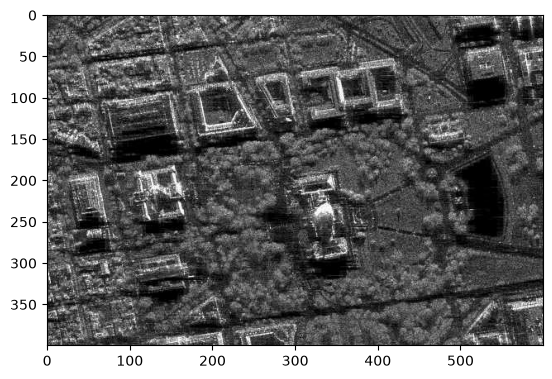

In [11]:
def color_correction_eq_gray(image):
    
    img_float = image.astype(np.float32)
    
    mean_b = np.mean(img_float[:, :, 0])
    mean_g = np.mean(img_float[:, :, 1])
    mean_r = np.mean(img_float[:, :, 2])
    
  
    mean_gray = (mean_b + mean_g + mean_r) / 3.0
    
    k_b = mean_gray / (mean_b + 1e-5)
    k_g = mean_gray / (mean_g + 1e-5)
    k_r = mean_gray / (mean_r + 1e-5)
    
    img_float[:, :, 0] *= k_b
    img_float[:, :, 1] *= k_g
    img_float[:, :, 2] *= k_r
    
    img_corrected = np.clip(img_float, 0, 255)
    
    return img_corrected.astype(np.uint8)

result = color_correction_eq_gray(image)
plt.imshow(result)

<h1>6. Пороговая фильтрация с различными параметрами</h1>

Text(0.5, 1.0, 'thresh=100')

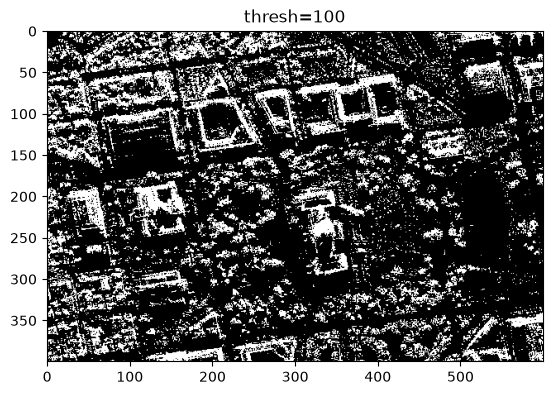

In [26]:
_, thresh_100 = cv2.threshold(image, 100, 255, cv2.THRESH_BINARY)
plt.imshow(thresh_100, cmap='gray')
plt.title('thresh=100')

Text(0.5, 1.0, 'thresh=150')

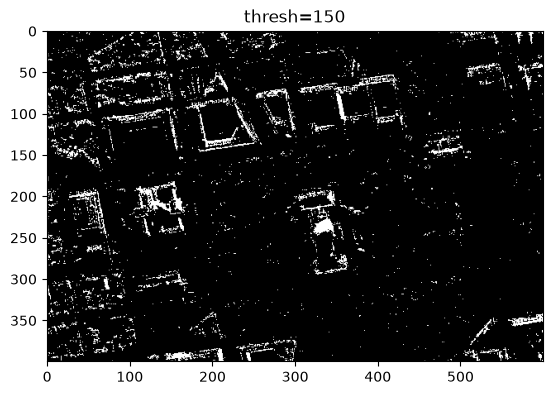

In [27]:
_, thresh_150 = cv2.threshold(image, 150, 255, cv2.THRESH_BINARY)
plt.imshow(thresh_150, cmap='gray')
plt.title('thresh=150')

Text(0.5, 1.0, 'thresh=200')

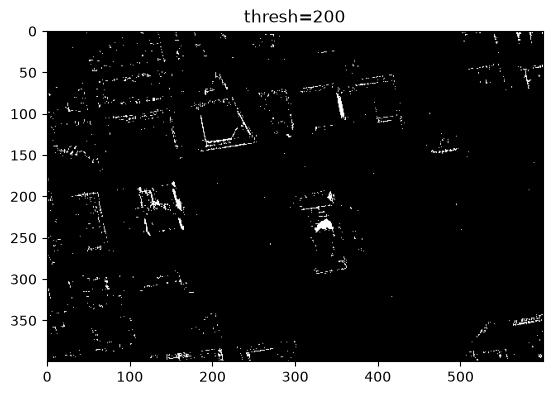

In [28]:
_, thresh_200 = cv2.threshold(image, 200, 255, cv2.THRESH_BINARY)
plt.imshow(thresh_200, cmap='gray')
plt.title('thresh=200')
